
# **Checking the wavelength mapping form different arc lamp (Ne, HgNe, HgAr) calibration**
---

The goal of this notebook is to check for a chosen y-line (vertical) of the detector, if the different calibration gives similar results, or if they differ.

## **0. Importing relevant libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.io import fits

%cd captures/

/Users/lalyboyer/Desktop/software/captures


## **1. Choosing detector y-line and arc lamps for comparaison**
---

In [2]:
LINE = 600 # avaialbe: 200, 600, 1000
lamp_hgar = fits.open(f'LAMP_HGNE_TEST2_lambda_ligne_{LINE}.fits')
lamp_ne = fits.open(f'LAMP_HGAR_lambda_ligne_{LINE}.fits')

## **2. Wavelength calibration comparaison**
---

If done correctly, for a given y-line, the wavelength calibration comparaison should give a **linear** relationship.

### **2.a) Linear fitting (first order test)**
--- 

In [3]:
# %matplotlib qt

r : 0.9999331023857083


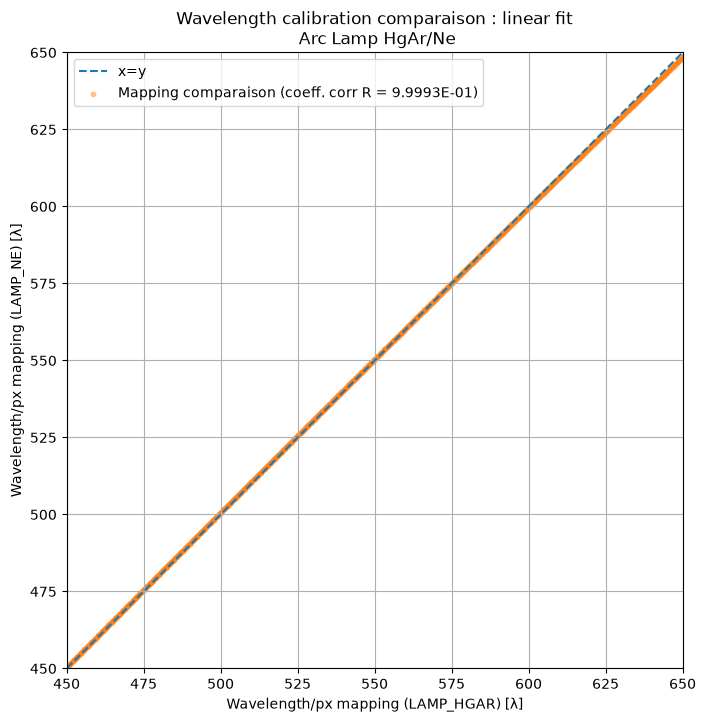

In [32]:
# extract data, flatten and align
data_hgar = np.asarray(lamp_hgar[0].data).ravel()
data_ne = np.asarray(lamp_ne[0].data).ravel()
n = min(data_hgar.size, data_ne.size)
x = data_hgar[:n]
y = data_ne[:n]

# remove non-finite values
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# optional subsample for performance
max_points = 200000
if x.size > max_points:
    idx = np.random.choice(x.size, max_points, replace=False)
    x = x[idx]
    y = y[idx]

# plot with seaborn and show Pearson r in title
r = np.corrcoef(x, y)[0, 1]
plt.figure(figsize=(8,8))
line = np.linspace(350,900,1000)
plt.plot(line,line,ls='--', label='x=y')
sns.regplot(x=x, y=y, scatter_kws={'s':10, 'alpha':0.4}, line_kws={'color':'red', 'lw':0},label=f'Mapping comparaison (coeff. corr R = {r:.4E})')
plt.xlabel('Wavelength/px mapping (LAMP_HGAR) [λ]')
plt.ylabel('Wavelength/px mapping (LAMP_NE) [λ]')
plt.title(f'Wavelength calibration comparaison : linear fit\n Arc Lamp HgAr/Ne')
# plt.title('Wavelength calibration comparaison\n2nd-degree polynomial fit (smile) ')
print(f'r : {r}')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
# a, b = 350,450
# a, b = 650,870
a, b = 450,650
plt.xlim(a,b)
plt.ylim(a,b)
plt.legend()
plt.show()

### **2.b) 2nd-degree polynomial fitting (detector smile)**
--- 

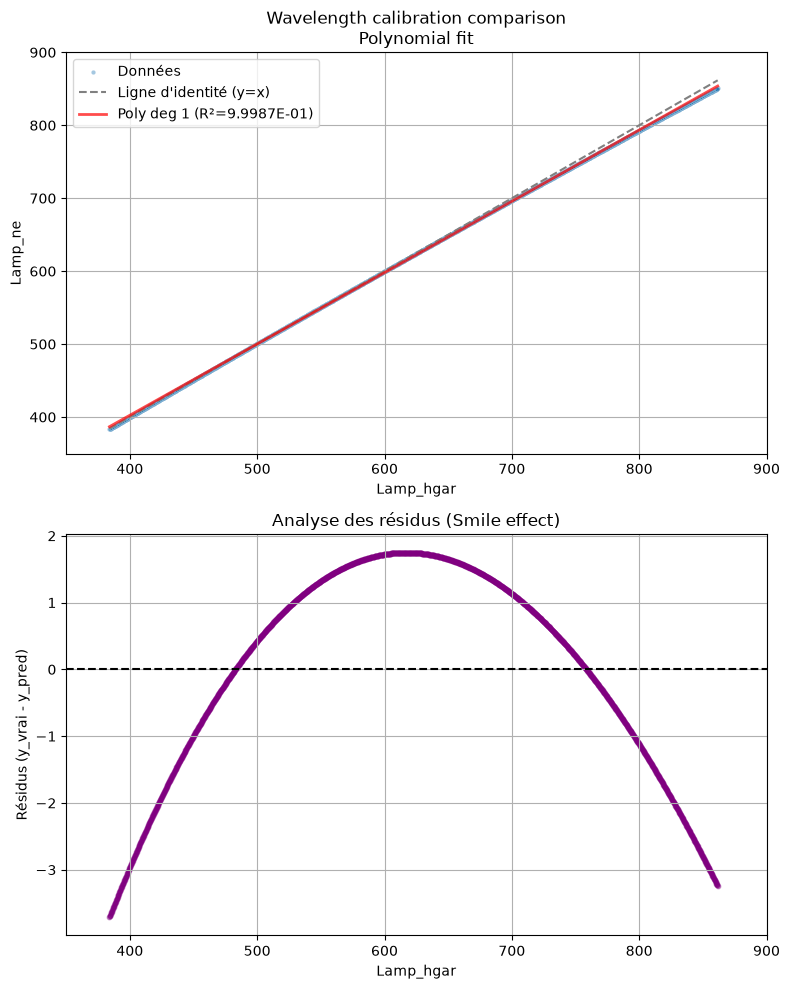

Coeffs (degré 1): [ 0.97777754 11.30793316]
R^2: 0.9998662092419336


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

degre = 1
coeffs = np.polyfit(x, y, degre)  
p = np.poly1d(coeffs)
y_pred = p(x)

# r**2
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=False)

sns.scatterplot(x=x, y=y, s=10, alpha=0.4, ax=ax1, label='Données')

xs = np.linspace(x.min(), x.max(), 1000)
ax1.plot(xs, xs, ls='--', color='gray', label='Ligne d\'identité (y=x)')
ax1.plot(xs, p(xs), color='red', lw=2, label=f'Poly deg {degre} (R²={r2:.4E})', alpha=0.7)

ax1.set_xlabel('Lamp_hgar')
ax1.set_ylabel('Lamp_ne')
ax1.set_title('Wavelength calibration comparison\nPolynomial fit')
ax1.legend()
ax1.grid(True)

# a, b = 370, 650
a,  b = 350,900
ax1.set_xlim(a, b)
ax1.set_ylim(a, b)


residus = y - y_pred
ax2.scatter(x, residus, s=10, alpha=0.4, color='purple')
ax2.axhline(0, color='black', ls='--')

ax2.set_xlabel('Lamp_hgar')
ax2.set_ylabel('Résidus (y_vrai - y_pred)')
ax2.set_title('Analyse des résidus (Smile effect)')
ax2.grid(True)
ax2.set_xlim(a, b)

plt.tight_layout()
plt.show()

print(f'Coeffs (degré {degre}):', coeffs)
print('R^2:', r2)